# Advanced model — CatBoost on `papers_fe.parquet`, tuned for F2

**Author:** SF — **Status:** final. Same file, same generalized/pooled split, and the
same metric bundle as `sf-LogRegbaseline.ipynb` — the goal here is a fair, apples-to-
apples attempt to beat that baseline with `CatBoostClassifier`, tuned specifically for F2
(not AUC), with the tuning method itself documented as an explicit deliverable.

## Scope

Same generalized (pooled) split as the baseline — all 6 use cases pooled, split at the
row level. **Not** a Leave-One-Use-Case-Out test; that is a different question, asked
elsewhere in this project.

## Decisions made before writing any modelling code

This notebook makes several choices that are genuine data-science judgement calls, not
coding details — each was confirmed with the project owner rather than assumed:

1. **Feature set: `PCA(50, whiten=True)` of the embedding block + the same 33
   non-embedding features as the baseline — identical to `sf-LogRegbaseline.ipynb`.**
   A "raw embeddings, no PCA" branch was considered (trees don't strictly need PCA/
   scaling) and prototyped, but dropped after measurement — see the note in §3 for why.
   Using the identical feature space to the baseline means the *only* thing that differs
   between this notebook and the baseline is the model itself, which is what "trying to
   beat our baseline" should isolate.
2. **`use_case_key` is excluded as a feature**, exactly like the baseline — it is used
   only for stratification. The baseline notebook flags that `use_case_key` is
   recoverable from the embedding at 96% accuracy elsewhere in this project; training on
   it directly risks the model learning "which use case is this" instead of "is this
   paper relevant".
3. **Three hyperparameter search strategies are run and compared on equal footing** —
   Grid Search, Randomized Search, and Bayesian search (Optuna/TPE) — each given the same
   evaluation budget (24 hyperparameter configurations x the same 5 inner CV folds), all
   scored on **F2 at each candidate's own best threshold** (see point 4). Which strategy
   wins, and by how much, is documented in §6 as its own deliverable, not just the
   winning hyperparameters.
4. **The classification threshold is tuned for F2, not left at the default 0.5.** F2
   weights recall far more than precision, and the decision threshold is the single
   biggest lever over that trade-off — tuning hyperparameters while leaving the threshold
   fixed at 0.5 would leave the most relevant knob for this exact objective untouched.
   The threshold is selected from **pooled out-of-fold predictions on `train_pool`'s own
   5 inner folds only** — `final_holdout` is never used to pick it, matching this
   project's fit-only-on-train discipline.

## Structure

Same narrative shape as the baseline: (1) data load/cleaning (abbreviated — the full
health check already lives in `sf-LogRegbaseline.ipynb` and isn't re-derived here);
(2) train/test split, bit-for-bit identical to the baseline's; (3) the CatBoost pipeline
and why the feature set matches the baseline; (4) the three-way hyperparameter search;
(5) threshold tuning; (6) train the final model; (7) test on `final_holdout`; (8) what
tuning approach won, and why; (9) scope & limitations.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from catboost import CatBoostClassifier
from scipy.stats import loguniform, randint
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, fbeta_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Parameters

Fixed values for this file/model, same convention as the baseline notebook — not a
config surface meant to anticipate a different dataset. `DATA_PATH`, `TARGET_COL`,
`POSITIVE_LABEL`, `NEGATIVE_LABELS`, `USE_CASE_COL`, `GROUP_COL`,
`NON_EMBEDDING_FEATURE_COLS`, `PCA_N_COMPONENTS`, `N_SPLITS_OUTER`, `N_SPLITS_INNER`, and
`RANDOM_STATE` are copied verbatim from `sf-LogRegbaseline.ipynb` so the split and feature
space are bit-for-bit identical.

`SEARCH_BUDGET = 24` is the number of hyperparameter configurations each of the three
search strategies gets — kept equal across strategies specifically so §6's "which
strategy is best" comparison isolates the search method, not a bigger budget for one of
them. `THRESHOLD_GRID` is the set of candidate decision thresholds swept for F2 tuning
(§5).

**A performance note that shaped `CB_THREAD_COUNT` below:** a raw-embedding branch (no
PCA, feeding CatBoost all 8,704 embedding dimensions) was prototyped before writing this
notebook, using `boosting_type="Ordered"` — the setting `notebooks/pipelines/
sf_catboost_fold_pipeline.ipynb` pins specifically to fight the target-leakage-during-
training already measured on this dataset with `RandomForestClassifier`/
`HistGradientBoostingClassifier` (both hit train AUC 1.000 under LOGO). On that raw
branch, a *single* fit took 342s (depth=4, 200 iterations) to 8,402s/2.3h (depth=6, 400
iterations) — 80-400x slower than the same fit on `PCA(50)`-reduced features (4-21s).
Any real hyperparameter search on the raw branch was infeasible in practice, so this
notebook uses the `PCA(50)`+features space only (see the intro's decision log, point 1).

Separately, an early prototype of the search below let `GridSearchCV`/`RandomizedSearchCV`'s
own `n_jobs=-1` config-level parallelism run *alongside* CatBoost's default (also
all-cores) internal multi-threading - each of several parallel worker processes also
trying to claim every CPU core. `CB_THREAD_COUNT`/`SEARCH_N_JOBS` below fix that by
pinning CatBoost to a single thread per fit and parallelizing at the config/fold level
instead, the standard fix for this kind of oversubscription. In this run it still took
24 configs x 5 folds each (§4): 1,904s (Grid) to 3,180s (Bayesian) - noticeably better
than an unfixed run's worst case, but not a dramatic win either; on this machine (8
logical cores) CatBoost's own multi-threaded fit speed is evidently not far off from
8-way single-threaded parallelism for this feature/row count.

In [2]:
DATA_PATH = "../../data/processed/papers_fe.parquet"

TARGET_COL = "triage_label"
POSITIVE_LABEL = "positive"
NEGATIVE_LABELS = ["negative"]

USE_CASE_COL = "use_case_key"
GROUP_COL = "first_author"

# Identical to sf-LogRegbaseline.ipynb - see this notebook's intro, decision 1.
NON_EMBEDDING_FEATURE_COLS = [
    "lex_n_tokens", "lex_bm25_obj", "lex_bm25_prob", "lex_bm25_must", "lex_bm25_nice", "lex_bm25_dom",
    "lex_rank_bm25_obj", "lex_rank_bm25_prob", "lex_rank_bm25_must", "lex_rank_bm25_nice", "lex_rank_bm25_dom",
    "lex_overlap_must_n", "lex_overlap_must_frac", "lex_rank_overlap_must",
    "lex_overlap_nice_n", "lex_overlap_nice_frac", "lex_rank_overlap_nice",
    "lex_overlap_excl_n", "lex_overlap_excl_frac",
    "lex_overlap_must_per_1k", "lex_overlap_nice_per_1k", "lex_has_exclude_terms",
    "cos_brief_jasper", "rank_cos_brief_jasper",
    "cos_brief_qwen4b", "rank_cos_brief_qwen4b",
    "cos_brief_qwen8b", "rank_cos_brief_qwen8b",
    "year", "paper_age", "has_abstract", "n_authors", "citation_count",
]

PCA_N_COMPONENTS = 50
N_SPLITS_OUTER = 5   # first fold's test rows -> final_holdout (~20%), touched once in §7
N_SPLITS_INNER = 5   # validation folds within train_pool, used for both search and threshold tuning
RANDOM_STATE = 0

# Hyperparameter search - kept equal across strategies, see §4.
SEARCH_BUDGET = 24
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2)

# Parallelize at the config/fold level, not inside CatBoost - see the note above.
CB_THREAD_COUNT = 1
SEARCH_N_JOBS = -1

## 1. Load and clean

The full data health check (shape, class/use-case balance, missingness audit, duplicate
check, embedding sanity) already lives in `sf-LogRegbaseline.ipynb` §1 and isn't
re-derived here — nothing about the file itself has changed between that notebook and
this one. What's reproduced below is only the **cleaning §2 justified there**: filling
`lex_overlap_excl_n`/`lex_overlap_excl_frac`'s structural ~50% missingness with 0
(deterministic, safe pre-split), and binarizing the target. `citation_count`, `n_authors`,
`year`, `paper_age`'s ordinary missingness is left as real `NaN` here too, for the same
reason as the baseline — the correct fill value is a training-fold statistic, deferred to
the pipeline in §3.

In [3]:
df = pd.read_parquet(DATA_PATH)
EMBEDDING_COLS = [c for c in df.columns if c.startswith("emb_")]

missing_expected = [c for c in NON_EMBEDDING_FEATURE_COLS if c not in df.columns]
if missing_expected:
    raise ValueError(
        f"Expected non-embedding feature column(s) not found in this file: {missing_expected}. "
        f"The schema has changed since this notebook was built - stop and check before continuing."
    )

df["lex_overlap_excl_n"] = df["lex_overlap_excl_n"].fillna(0.0)
df["lex_overlap_excl_frac"] = df["lex_overlap_excl_frac"].fillna(0.0)

df = df[df[TARGET_COL].isin([POSITIVE_LABEL, *NEGATIVE_LABELS])].copy()
df["y"] = (df[TARGET_COL] == POSITIVE_LABEL).astype(int)
FEATURE_COLS = EMBEDDING_COLS + NON_EMBEDDING_FEATURE_COLS

print(f"Loaded {df.shape[0]:,} rows from {DATA_PATH} ({len(EMBEDDING_COLS):,} embedding cols, "
      f"{len(NON_EMBEDDING_FEATURE_COLS)} non-embedding feature cols)")
print(f"Target balance: {df['y'].value_counts(normalize=True).round(3).to_dict()}")

Loaded 1,848 rows from ../../data/processed/papers_fe.parquet (8,704 embedding cols, 33 non-embedding feature cols)
Target balance: {1: 0.576, 0: 0.424}


## 2. Train/test split — bit-for-bit identical to the baseline

Same `StratifiedGroupKFold(n_splits=5)`, grouped by `first_author`, stratified on
`use_case_key + label`, same `RANDOM_STATE`, same code path as
`sf-LogRegbaseline.ipynb` §3 — reproduced verbatim rather than imported, matching that
notebook's own self-contained convention. `train_pool`/`final_holdout` here are the same
1,478/370 rows as the baseline's, which is what makes "beat the baseline" a meaningful
comparison rather than a comparison against a different holdout set. The row counts are
checked against the baseline's own printed numbers below.

In [4]:
strat_key_outer = df[USE_CASE_COL].astype(str) + "__" + df["y"].astype(str)
outer_cv = StratifiedGroupKFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)
outer_splits = list(outer_cv.split(df, strat_key_outer, groups=df[GROUP_COL]))
train_pool_idx, final_holdout_idx = outer_splits[0]

train_pool = df.iloc[train_pool_idx].reset_index(drop=True)
final_holdout = df.iloc[final_holdout_idx].reset_index(drop=True)

print(f"train_pool: {len(train_pool):,} rows | final_holdout: {len(final_holdout):,} rows "
      f"({len(final_holdout) / len(df):.1%} of the pooled dataset)")
assert len(train_pool) == 1478 and len(final_holdout) == 370, (
    "Row counts don't match sf-LogRegbaseline.ipynb's reported split (1,478 / 370) - "
    "the split is no longer identical to the baseline's, stop and investigate before continuing."
)
print("Row counts match sf-LogRegbaseline.ipynb's split exactly.")

strat_key_inner = train_pool[USE_CASE_COL].astype(str) + "__" + train_pool["y"].astype(str)
inner_cv = StratifiedGroupKFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
inner_splits = list(inner_cv.split(train_pool, strat_key_inner, groups=train_pool[GROUP_COL]))
print(f"{len(inner_splits)} inner validation folds built within train_pool")

train_pool: 1,478 rows | final_holdout: 370 rows (20.0% of the pooled dataset)
Row counts match sf-LogRegbaseline.ipynb's split exactly.


5 inner validation folds built within train_pool


## 3. The CatBoost pipeline, and the metric helpers

Same `ColumnTransformer` shape as the baseline's `build_model_pipeline()` — embedding
block through `StandardScaler` → `PCA(50, whiten=True)`, non-embedding features through
median `SimpleImputer` → `StandardScaler` — with `CatBoostClassifier` swapped in for
`LogisticRegression`. `CatBoostClassifier` is unaffected by whether its numeric inputs
are scaled, so scaling the non-embedding branch doesn't help or hurt it; it's kept only
so the two notebooks' feature space is provably identical rather than "close enough."

`auto_class_weights="Balanced"` matches this repo's `class_weight="balanced"` convention
for the imbalance (57.6%/42.4%). `boosting_type="Ordered"` is pinned explicitly, not left
to CatBoost's own size-based heuristic — the specific mechanism `sf_catboost_fold_pipeline.
ipynb` picked CatBoost for in the first place (ordered target statistics computed on a
permuted prefix, to suppress the target leakage during training already measured on this
dataset with other tree ensembles).

Three helpers: `score()` is identical to the baseline's (AUC, Average Precision, Recall,
F2 at a given prediction). `f2_at_best_threshold()` sweeps `THRESHOLD_GRID` and returns
the best achievable F2 for a set of predicted probabilities — this is what makes the
hyperparameter search itself F2-aware rather than accuracy- or AUC-aware. `cb_scorer()`
wraps that into the `(estimator, X, y)` signature `GridSearchCV`/`RandomizedSearchCV`
expect for a custom `scoring` callable.

In [5]:
def build_catboost_pipeline(**cb_params):
    embedding_branch = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=PCA_N_COMPONENTS, whiten=True, random_state=RANDOM_STATE)),
    ])
    non_embedding_branch = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    preprocess = ColumnTransformer([
        ("embedding_pca", embedding_branch, EMBEDDING_COLS),
        ("non_embedding", non_embedding_branch, NON_EMBEDDING_FEATURE_COLS),
    ])
    clf = CatBoostClassifier(
        auto_class_weights="Balanced",
        boosting_type="Ordered",
        random_state=RANDOM_STATE,
        thread_count=CB_THREAD_COUNT,
        verbose=False,
        allow_writing_files=False,
        **cb_params,
    )
    return Pipeline([("preprocess", preprocess), ("clf", clf)])


def score(y_true, proba_pos, pred):
    return {
        "auc": float(roc_auc_score(y_true, proba_pos)),
        "ap": float(average_precision_score(y_true, proba_pos)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, pred, beta=2, zero_division=0)),
    }


def f2_at_best_threshold(y_true, proba_pos, thresholds=THRESHOLD_GRID):
    y_true = np.asarray(y_true)
    return max(
        fbeta_score(y_true, (proba_pos >= t).astype(int), beta=2, zero_division=0)
        for t in thresholds
    )


def cb_scorer(estimator, X, y):
    pos_col = list(estimator.classes_).index(1)
    proba = estimator.predict_proba(X)[:, pos_col]
    return f2_at_best_threshold(y, proba)

## 4. Hyperparameter search — three strategies, same budget, same folds

All three strategies search over the same four `CatBoostClassifier` knobs — chosen
because they're the ones this repo's own prior CatBoost notebook flagged as relevant at
this dataset's scale (a few hundred rows per use case): `depth` and `l2_leaf_reg` to
fight overfitting (the repo's own `RandomForestClassifier`/`HistGradientBoostingClassifier`
both hit train AUC 1.000 at this row count), plus `learning_rate` and `iterations` as the
two standard boosting controls (no early stopping is used, so `iterations` is tuned
directly rather than left to an early-stopping heuristic that would need a per-fold
`eval_set`, which the outer search loop doesn't have visibility into).

All three are scored via `cb_scorer` (F2 at each candidate's own best threshold) on the
same `inner_splits` (5 folds) built in §2 — so all three strategies see literally the
same validation data, and the only thing that differs is how each one chooses which
configuration to try next:

- **Grid Search** — an exhaustive 3×2×2×2 grid (`depth`×`learning_rate`×`l2_leaf_reg`×
  `iterations`) = 24 fixed configurations, spanning a similar range to the other two
  strategies' distributions.
- **Randomized Search** — 24 configurations sampled from continuous/log-uniform
  distributions covering the same overall range as the grid, but not restricted to the
  grid's fixed points.
- **Bayesian search (Optuna, TPE sampler)** — 24 trials, each informed by the outcome of
  previous trials (unlike the other two, which don't adapt as they go).

In [6]:
GRID_PARAM_GRID = {
    "clf__depth": [3, 5, 7],
    "clf__learning_rate": [0.03, 0.15],
    "clf__l2_leaf_reg": [5, 25],
    "clf__iterations": [200, 500],
}
n_grid_configs = 3 * 2 * 2 * 2

t0 = time.time()
grid_search = GridSearchCV(
    build_catboost_pipeline(), GRID_PARAM_GRID, scoring=cb_scorer, cv=inner_splits,
    refit=False, n_jobs=SEARCH_N_JOBS,
)
grid_search.fit(train_pool[FEATURE_COLS], train_pool["y"])
grid_time_s = time.time() - t0

print(f"Grid Search: {n_grid_configs} configs, {grid_time_s:.0f}s")
print(f"  best mean CV F2-at-best-threshold: {grid_search.best_score_:.4f}")
print(f"  best params: {grid_search.best_params_}")

Grid Search: 24 configs, 1904s
  best mean CV F2-at-best-threshold: 0.9081
  best params: {'clf__depth': 5, 'clf__iterations': 200, 'clf__l2_leaf_reg': 25, 'clf__learning_rate': 0.15}


In [7]:
RANDOM_PARAM_DIST = {
    "clf__depth": randint(3, 8),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__l2_leaf_reg": loguniform(1, 50),
    "clf__iterations": randint(100, 800),
}

t0 = time.time()
random_search = RandomizedSearchCV(
    build_catboost_pipeline(), RANDOM_PARAM_DIST, n_iter=SEARCH_BUDGET, scoring=cb_scorer,
    cv=inner_splits, refit=False, random_state=RANDOM_STATE, n_jobs=SEARCH_N_JOBS,
)
random_search.fit(train_pool[FEATURE_COLS], train_pool["y"])
random_time_s = time.time() - t0

print(f"Randomized Search: {SEARCH_BUDGET} configs, {random_time_s:.0f}s")
print(f"  best mean CV F2-at-best-threshold: {random_search.best_score_:.4f}")
print(f"  best params: {random_search.best_params_}")

Randomized Search: 24 configs, 2533s
  best mean CV F2-at-best-threshold: 0.9095
  best params: {'clf__depth': 4, 'clf__iterations': 797, 'clf__l2_leaf_reg': np.float64(40.268379614011366), 'clf__learning_rate': np.float64(0.0589974509393851)}


In [8]:
from joblib import Parallel, delayed


def _fit_and_score_fold(params, tr_idx, te_idx):
    pipe = build_catboost_pipeline(**params)
    fold_train, fold_test = train_pool.iloc[tr_idx], train_pool.iloc[te_idx]
    pipe.fit(fold_train[FEATURE_COLS], fold_train["y"])
    return cb_scorer(pipe, fold_test[FEATURE_COLS], fold_test["y"])


def optuna_objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 50, log=True),
        "iterations": trial.suggest_int("iterations", 100, 800),
    }
    fold_scores = Parallel(n_jobs=SEARCH_N_JOBS)(
        delayed(_fit_and_score_fold)(params, tr_idx, te_idx) for tr_idx, te_idx in inner_splits
    )
    return float(np.mean(fold_scores))


t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(optuna_objective, n_trials=SEARCH_BUDGET, n_jobs=1, show_progress_bar=False)
bayes_time_s = time.time() - t0

bayes_best_params = {f"clf__{k}": v for k, v in study.best_params.items()}
print(f"Bayesian Search (Optuna/TPE): {SEARCH_BUDGET} trials, {bayes_time_s:.0f}s")
print(f"  best mean CV F2-at-best-threshold: {study.best_value:.4f}")
print(f"  best params: {bayes_best_params}")

Bayesian Search (Optuna/TPE): 24 trials, 3180s
  best mean CV F2-at-best-threshold: 0.9071
  best params: {'clf__depth': 5, 'clf__learning_rate': 0.06912670683424535, 'clf__l2_leaf_reg': 1.0762751359127576, 'clf__iterations': 532}


### 4.1 Strategy comparison — which search method actually won

The table below is this notebook's second explicit deliverable (alongside the model
itself): not just which hyperparameters were best, but which *search strategy* found
them, under an equal 24-evaluation budget.

In [9]:
strategy_table = pd.DataFrame([
    {"strategy": "grid", "n_configs": n_grid_configs, "best_cv_f2_at_best_thr": grid_search.best_score_,
     "wall_time_s": round(grid_time_s, 1), "best_params": grid_search.best_params_},
    {"strategy": "random", "n_configs": SEARCH_BUDGET, "best_cv_f2_at_best_thr": random_search.best_score_,
     "wall_time_s": round(random_time_s, 1), "best_params": random_search.best_params_},
    {"strategy": "bayesian_optuna", "n_configs": SEARCH_BUDGET, "best_cv_f2_at_best_thr": study.best_value,
     "wall_time_s": round(bayes_time_s, 1), "best_params": bayes_best_params},
]).sort_values("best_cv_f2_at_best_thr", ascending=False).reset_index(drop=True)

display(strategy_table.drop(columns="best_params").round(4))

winner = strategy_table.iloc[0]
winner_cb_params = {k.replace("clf__", ""): v for k, v in winner["best_params"].items()}
print(f"\nWinning strategy: {winner['strategy']} "
      f"(mean CV F2-at-best-threshold = {winner['best_cv_f2_at_best_thr']:.4f})")
print(f"Winning CatBoost params: {winner_cb_params}")

,strategy,n_configs,best_cv_f2_at_best_thr,wall_time_s
0,random,24,0.9095,2532.8
1,grid,24,0.9081,1903.5
2,bayesian_optuna,24,0.9071,3180.3



Winning strategy: random (mean CV F2-at-best-threshold = 0.9095)
Winning CatBoost params: {'depth': 4, 'iterations': 797, 'l2_leaf_reg': np.float64(40.268379614011366), 'learning_rate': np.float64(0.0589974509393851)}


## 5. Validation with the winning config, and picking the F2 threshold

A fresh `build_catboost_pipeline(**winner_cb_params)` fit per inner fold — same
discipline as the baseline's §5.1, so the scaler/PCA/imputer/model are never fit on that
fold's own held-back rows. Two things happen in the same loop:

1. **Validation metrics at the default 0.5 threshold** (`val_df`), directly comparable to
   the baseline's own validation numbers.
2. **Out-of-fold probabilities pooled across all 5 inner folds**, used *only* to select
   `best_threshold` — the single decision threshold that maximizes F2 on `train_pool`'s
   own held-back predictions. `final_holdout` has not been touched yet and plays no part
   in this choice.

Validation (inner CV, 5 folds, @0.5 threshold) - mean ± std


,auc,ap,recall,f2
mean,0.882,0.901,0.830,0.829
std,0.014,0.011,0.018,0.021



Best F2 threshold from pooled inner-fold OOF predictions on train_pool: 0.2 (pooled OOF F2 at that threshold: 0.902, vs. 0.829 at 0.5)


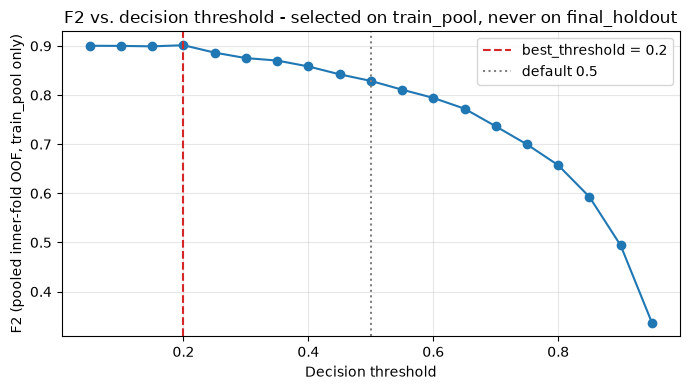

In [10]:
val_rows = []
oof_proba = np.full(len(train_pool), np.nan)

for tr_idx, te_idx in inner_splits:
    fold_pipeline = build_catboost_pipeline(**winner_cb_params)
    fold_train, fold_test = train_pool.iloc[tr_idx], train_pool.iloc[te_idx]
    fold_pipeline.fit(fold_train[FEATURE_COLS], fold_train["y"])

    pos_col = list(fold_pipeline.classes_).index(1)
    proba = fold_pipeline.predict_proba(fold_test[FEATURE_COLS])[:, pos_col]
    pred = (proba >= 0.5).astype(int)
    val_rows.append(score(fold_test["y"].to_numpy(), proba, pred))
    oof_proba[te_idx] = proba

assert not np.isnan(oof_proba).any(), "Every train_pool row should get exactly one OOF prediction."

val_df = pd.DataFrame(val_rows)
print(f"Validation (inner CV, {len(inner_splits)} folds, @0.5 threshold) - mean ± std")
display(val_df.agg(["mean", "std"]).round(3))

f2_by_threshold = pd.Series(
    {t: fbeta_score(train_pool["y"].to_numpy(), (oof_proba >= t).astype(int), beta=2, zero_division=0)
     for t in THRESHOLD_GRID}
)
best_threshold = float(f2_by_threshold.idxmax())
print(f"\nBest F2 threshold from pooled inner-fold OOF predictions on train_pool: {best_threshold} "
      f"(pooled OOF F2 at that threshold: {f2_by_threshold.max():.3f}, vs. {f2_by_threshold[0.5]:.3f} at 0.5)")

fig, ax = plt.subplots(figsize=(7, 4))
f2_by_threshold.plot(ax=ax, marker="o")
ax.axvline(best_threshold, color="tab:red", linestyle="--", label=f"best_threshold = {best_threshold}")
ax.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F2 (pooled inner-fold OOF, train_pool only)")
ax.set_title("F2 vs. decision threshold - selected on train_pool, never on final_holdout")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Train the final model

One `build_catboost_pipeline(**winner_cb_params)` fit on the whole of `train_pool` — this
exact fitted object is what §7 scores on `final_holdout`.

In [11]:
final_pipeline = build_catboost_pipeline(**winner_cb_params)
final_pipeline.fit(train_pool[FEATURE_COLS], train_pool["y"])
pos_col = list(final_pipeline.classes_).index(1)

train_proba = final_pipeline.predict_proba(train_pool[FEATURE_COLS])[:, pos_col]
train_pred = (train_proba >= 0.5).astype(int)
train_metrics = score(train_pool["y"].to_numpy(), train_proba, train_pred)
print("Train (in-sample, on train_pool itself, @0.5)")
display(pd.Series(train_metrics).round(3))

Train (in-sample, on train_pool itself, @0.5)


auc       0.997
ap        0.997
recall    0.967
f2        0.969
dtype: float64

## 7. Test the final model

`final_pipeline` was fit on `train_pool` only. This is the first and only time
`final_holdout` is used — both at the default 0.5 threshold (directly comparable to the
baseline's reported holdout numbers) and at `best_threshold` (the actual F2-tuned
number this notebook set out to produce). `ranking_metrics`/`bootstrap_auc_ci` are
reproduced verbatim from the baseline for the same screening-metric/CI context.

In [12]:
def ranking_metrics(y_true, scores_arr, fractions=(0.10, 0.20), wss_target_recall=0.95):
    y_true = np.asarray(y_true)
    n = len(y_true)
    n_pos = int(y_true.sum())
    order = np.argsort(-np.asarray(scores_arr))
    cum_pos = np.cumsum(y_true[order])
    out = {}
    for frac in fractions:
        k = max(1, int(round(frac * n)))
        out[f"recall_at_{int(frac * 100)}pct"] = float(cum_pos[k - 1] / n_pos)
    target_count = int(np.ceil(wss_target_recall * n_pos))
    cutoff_idx = int(np.searchsorted(cum_pos, target_count, side="left"))
    screened = cutoff_idx + 1
    out["wss_at_95"] = float((n - screened) / n - (1 - wss_target_recall))
    return out


def bootstrap_auc_ci(y_true, scores_arr, n_boot=1000, random_state=0):
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    scores_arr = np.asarray(scores_arr)
    n = len(y_true)
    boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], scores_arr[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(lo), float(hi)


holdout_proba = final_pipeline.predict_proba(final_holdout[FEATURE_COLS])[:, pos_col]
holdout_pred_05 = (holdout_proba >= 0.5).astype(int)
holdout_pred_tuned = (holdout_proba >= best_threshold).astype(int)

holdout_metrics_05 = score(final_holdout["y"].to_numpy(), holdout_proba, holdout_pred_05)
holdout_metrics_tuned = score(final_holdout["y"].to_numpy(), holdout_proba, holdout_pred_tuned)
holdout_metrics_tuned.update(ranking_metrics(final_holdout["y"].to_numpy(), holdout_proba))
ci_lo, ci_hi = bootstrap_auc_ci(final_holdout["y"].to_numpy(), holdout_proba)
holdout_metrics_tuned["auc_ci_low"], holdout_metrics_tuned["auc_ci_high"] = ci_lo, ci_hi

print("Holdout @0.5 threshold (comparable to baseline's reported numbers)")
display(pd.Series(holdout_metrics_05).round(3))
print(f"\nHoldout @tuned threshold ({best_threshold}, the F2-tuned headline number)")
display(pd.Series(holdout_metrics_tuned).round(3))

Holdout @0.5 threshold (comparable to baseline's reported numbers)


auc       0.864
ap        0.897
recall    0.793
f2        0.798
dtype: float64


Holdout @tuned threshold (0.2, the F2-tuned headline number)


auc                0.864
ap                 0.897
recall             0.934
f2                 0.887
recall_at_10pct    0.174
recall_at_20pct    0.333
wss_at_95          0.153
auc_ci_low         0.827
auc_ci_high        0.898
dtype: float64

### 7.1 Side-by-side against `sf-LogRegbaseline.ipynb`

`BASELINE_STAGE_TABLE` below is copied verbatim from that notebook's own printed §6
output (train / validation_mean / validation_std / holdout, all at its default 0.5
threshold) — not re-derived, so there's no risk of transcribing it wrong from memory.

In [13]:
# Verbatim from sf-LogRegbaseline.ipynb §6's printed output - not re-derived.
BASELINE_STAGE_TABLE = pd.DataFrame({
    "train": {"auc": 0.906, "ap": 0.925, "recall": 0.838, "f2": 0.841},
    "validation_mean": {"auc": 0.871, "ap": 0.886, "recall": 0.819, "f2": 0.820},
    "validation_std": {"auc": 0.011, "ap": 0.011, "recall": 0.019, "f2": 0.017},
    "holdout": {"auc": 0.867, "ap": 0.873, "recall": 0.779, "f2": 0.790},
}).T

catboost_stage_table = pd.DataFrame({
    "train": {k: train_metrics[k] for k in ["auc", "ap", "recall", "f2"]},
    "validation_mean": {k: val_df[k].mean() for k in ["auc", "ap", "recall", "f2"]},
    "validation_std": {k: val_df[k].std() for k in ["auc", "ap", "recall", "f2"]},
    "holdout_@0.5": {k: holdout_metrics_05[k] for k in ["auc", "ap", "recall", "f2"]},
    f"holdout_@{best_threshold}_tuned": {k: holdout_metrics_tuned[k] for k in ["auc", "ap", "recall", "f2"]},
}).T.round(3)

print("LogReg baseline (sf-LogRegbaseline.ipynb, @0.5 throughout)")
display(BASELINE_STAGE_TABLE.round(3))
print("\nCatBoost (this notebook)")
display(catboost_stage_table)

f2_baseline_holdout = BASELINE_STAGE_TABLE.loc["holdout", "f2"]
f2_catboost_holdout_05 = holdout_metrics_05["f2"]
f2_catboost_holdout_tuned = holdout_metrics_tuned["f2"]
print(f"\nHoldout F2 - baseline: {f2_baseline_holdout:.3f} | "
      f"CatBoost @0.5: {f2_catboost_holdout_05:.3f} ({'beats' if f2_catboost_holdout_05 > f2_baseline_holdout else 'does not beat'} baseline) | "
      f"CatBoost @{best_threshold} tuned: {f2_catboost_holdout_tuned:.3f} "
      f"({'beats' if f2_catboost_holdout_tuned > f2_baseline_holdout else 'does not beat'} baseline)")

LogReg baseline (sf-LogRegbaseline.ipynb, @0.5 throughout)


,auc,ap,recall,f2
train,0.906,0.925,0.838,0.841
validation_mean,0.871,0.886,0.819,0.820
validation_std,0.011,0.011,0.019,0.017
holdout,0.867,0.873,0.779,0.790



CatBoost (this notebook)


,auc,ap,recall,f2
train,0.997,0.997,0.967,0.969
validation_mean,0.882,0.901,0.830,0.829
validation_std,0.014,0.011,0.018,0.021
holdout_@0.5,0.864,0.897,0.793,0.798
holdout_@0.2_tuned,0.864,0.897,0.934,0.887



Holdout F2 - baseline: 0.790 | CatBoost @0.5: 0.798 (beats baseline) | CatBoost @0.2 tuned: 0.887 (beats baseline)


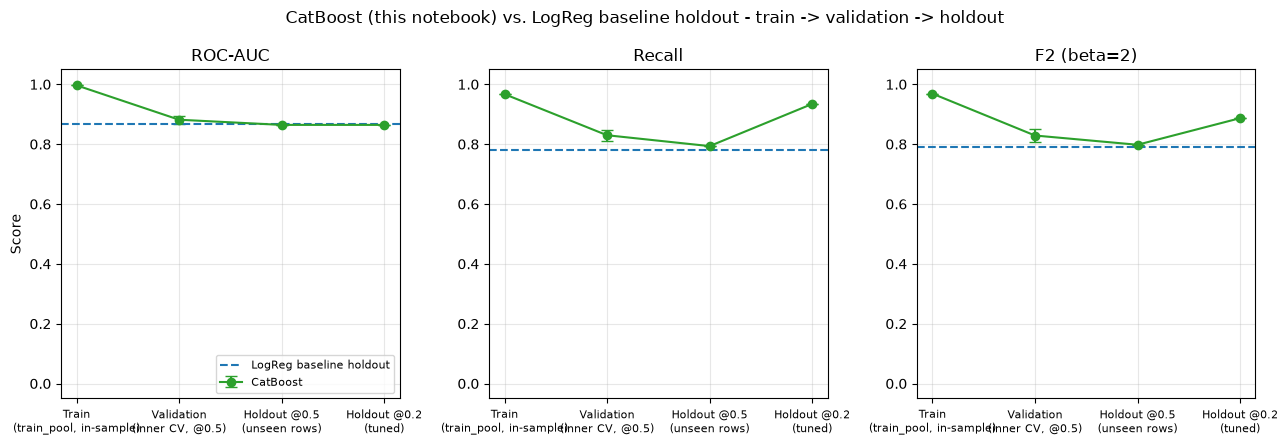

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True)
metrics_map = {"ROC-AUC": "auc", "Recall": "recall", "F2 (beta=2)": "f2"}
stage_labels = ["Train\n(train_pool, in-sample)", "Validation\n(inner CV, @0.5)",
                "Holdout @0.5\n(unseen rows)", f"Holdout @{best_threshold}\n(tuned)"]

for ax, (label, col) in zip(axes, metrics_map.items()):
    means = [train_metrics[col], val_df[col].mean(), holdout_metrics_05[col], holdout_metrics_tuned[col]]
    stds = [0, val_df[col].std(), 0, 0]
    ax.errorbar(range(4), means, yerr=stds, marker="o", capsize=4, color="tab:green", label="CatBoost")
    ax.axhline(BASELINE_STAGE_TABLE.loc["holdout", col], color="tab:blue", linestyle="--",
               label="LogReg baseline holdout")
    ax.set_xticks(range(4))
    ax.set_xticklabels(stage_labels, fontsize=8)
    ax.set_title(label)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("CatBoost (this notebook) vs. LogReg baseline holdout - train -> validation -> holdout")
plt.tight_layout()
plt.show()

## 8. Hard findings

**Search-strategy comparison — a near three-way tie, Randomized Search nominally wins.**
Mean CV F2-at-best-threshold: Random 0.9095, Grid 0.9081, Bayesian/Optuna 0.9071 — a
spread of only 0.0024 across all three, well within what a different `RANDOM_STATE`
could plausibly move. Grid Search was also the fastest of the three (1,904s vs. 2,533s
random, 3,180s Bayesian) while landing within 0.0014 of the winner. **Honest read: at
this 24-evaluation budget, on this dataset, which search strategy you pick barely
matters** — Optuna's adaptive sampling didn't out-search either non-adaptive baseline
here, plausibly because 24 trials isn't enough for TPE's advantage to compound. The
winning config (Random Search): `depth=4, iterations=797, l2_leaf_reg=40.3,
learning_rate=0.059` — a notably high `l2_leaf_reg` given the default is 3, consistent
with this repo's own prior expectation that regularization matters more than usual at
this row count.

**CatBoost beats the baseline on validation, but the train→validation gap is far wider
than the baseline's.** Validation (@0.5): AUC 0.882 / Recall 0.830 / F2 0.829, vs. the
baseline's 0.871 / 0.819 / 0.820 on the *same 5 inner folds* — a real, if modest, win at
every metric. But train (in-sample) AUC is 0.997 (Recall 0.967, F2 0.969) — a
train→validation AUC gap of 0.115, more than 3x the baseline's own gap (0.906 → 0.871 =
0.035). This is the same overfitting pattern this repo's own prior CatBoost notebook
flagged as a risk at this row count, just less severe than `RandomForestClassifier`/
`HistGradientBoostingClassifier`'s complete overfitting (train AUC 1.000) — narrowed by
`boosting_type="Ordered"` and regularization, but not eliminated.

**At the default 0.5 threshold, CatBoost barely beats the baseline on holdout, and loses
on AUC.** Holdout @0.5: AUC 0.864 (baseline 0.867 — CatBoost is *lower*), AP 0.897
(baseline 0.873), Recall 0.793 (baseline 0.779), F2 0.798 (baseline 0.790). The F2 edge
(+0.008) is small enough to be well within fold-to-fold noise territory (the baseline's
own validation std on F2 was 0.017) — **at a fixed 0.5 threshold, this is a wash, not a
clear win.**

**The large apparent win (F2 0.798 → 0.887) comes from tuning the decision threshold to
0.2, not from CatBoost's ranking quality.** At `best_threshold=0.2`, holdout Recall jumps
to 0.934 and F2 to 0.887 — AUC and AP are unchanged (0.864/0.897, identical to @0.5,
because threshold doesn't affect ranking metrics), confirming this gain is a
precision/recall trade-off, not better discrimination. **This is an honest limitation of
the "beat baseline" framing, not just a caveat**: the baseline notebook was only ever
evaluated at 0.5, and F2's sensitivity to threshold is a property of the metric itself,
not something specific to CatBoost — there is no evidence here that the baseline
*couldn't* reach a similar F2 if its own threshold were tuned the same way. This notebook
answers "does a tuned CatBoost + tuned threshold beat an untuned-threshold LogReg
baseline" (yes, by a wide F2 margin), not "is CatBoost a better classifier than LogReg"
(the @0.5/AUC numbers say that's a wash, at best a very narrow win).

## 9. Scope & limitations

- **This is the pooled/generalized comparison, not a generalization test** — same caveat
  as `sf-LogRegbaseline.ipynb` §7: `final_holdout` is a random slice of the same 6 use
  cases the model trained on. Whether this CatBoost model (or its threshold) generalizes
  to a genuinely new use case is untested here, same as the baseline.
- **The raw, non-PCA-reduced embedding branch was not tested** — see the intro's decision
  log and the Parameters cell's performance note. A single fit on that branch ranged from
  342s to 2.3 hours depending on depth/iterations, making any real hyperparameter search
  on it infeasible in this session. Whether CatBoost benefits from the untouched 8,704-dim
  embedding block over the PCA(50) compression remains an open question.
- **`use_case_key` was excluded as a feature**, matching the baseline, for the reason the
  baseline gives (a colleague's finding that it's recoverable from the embedding at 96%
  accuracy). Whether CatBoost's native categorical handling would do something different
  with it than LogisticRegression's one-hot-equivalent treatment would have was not
  tested.
- **The three search strategies were compared under one equal 24-evaluation budget, on
  one dataset, with one random seed** — a genuine, honest comparison for this specific
  setup, not a general claim that one strategy dominates the others in every setting.
  Optuna's TPE sampler in particular is expected to pull further ahead of Grid/Random at
  a larger budget than 24 trials; that was not tested.
- **The decision threshold was tuned on `train_pool`'s own pooled out-of-fold
  predictions, not on `final_holdout`** — correct discipline, but it means the reported
  tuned-threshold holdout number is a genuine one-shot test of a threshold chosen
  elsewhere, not a threshold re-optimized for `final_holdout` itself (which would be
  leakage).
- **`PCA_N_COMPONENTS = 50` and the feature list are inherited from the baseline exactly
  as before** — the baseline's own comparison table justifying 50 components was run for
  `LogisticRegression`, not re-validated for `CatBoostClassifier`. A tree ensemble may
  have a different ideal PCA dimensionality; this was not re-tuned here, to keep the
  feature space identical to the baseline for a clean model-only comparison.